# Modeling — ICU Mortality Risk Stratification

This notebook trains, compares, and evaluates four classification models for predicting
hospital mortality in ICU patients.  Every decision is documented as it would appear in
a clinical ML methods section: why this split ratio, why this metric, why this threshold.

**Target**: `hospital_death` (binary, ~8.6% positive rate)
**Input**: `data/processed/features_engineered.csv`

In [1]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc,
    ConfusionMatrixDisplay, confusion_matrix,
    classification_report, f1_score, precision_score, recall_score,
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE

from src.models import get_model, tune, train, evaluate, save_model, load_model
from src.preprocessing import scale_numeric

plt.style.use("seaborn-v0_8-whitegrid")
FIGURES_DIR = Path("../reports/figures")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SURVIVED_COLOR = "#4878d0"
DIED_COLOR     = "#ee854a"
RANDOM_STATE   = 42
TARGET         = "hospital_death"

df = pd.read_csv(PROCESSED_DIR / "features_engineered.csv")

# Drop all string/object columns (age_group kept for fairness; icu_stay_type not encoded)
obj_cols = [c for c in df.columns if df[c].dtype == "object"]
if obj_cols:
    print(f"Dropping non-numeric columns: {obj_cols}")
    df = df.drop(columns=obj_cols)

# Fill any remaining NaN with column medians — feature engineering imputes vitals/labs
# by group but some columns (age, apache scores, GCS) may have residual missingness.
# Median is used rather than mean for robustness to skewed ICU distributions.
nan_before = df.isnull().sum().sum()
if nan_before:
    df = df.fillna(df.median(numeric_only=True))
    print(f"Median-imputed {nan_before:,} residual NaN values across {df.isnull().sum().sum() == 0 and 'all columns' or 'some columns'}")

print(f"Loaded: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Target rate: {df[TARGET].mean()*100:.2f}%")
print(f"Remaining NaN: {df.isnull().sum().sum()}")

Dropping non-numeric columns: ['icu_stay_type', 'age_group']
Median-imputed 103,121 residual NaN values across all columns
Loaded: 91,713 rows  x  79 columns
Target rate: 8.63%
Remaining NaN: 0


---
## Section 1 — Train / Validation / Test Split

We use a **70 / 15 / 15 stratified split** on `hospital_death`.  Stratification is not
optional here — with only ~8.6% positive rate a random split would produce test sets with
substantially different mortality rates by chance, making performance estimates unreliable.

We save the exact test-set indices to disk so the fairness audit (notebook 05) evaluates
on the same patients used here.  Using different splits for modeling vs. fairness would
make comparisons meaningless.

In [2]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 70 / 15 / 15 stratified split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
val_frac = 0.15 / 0.85  # 15% of total drawn from the 85% train+val pool
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_frac, stratify=y_trainval, random_state=RANDOM_STATE
)

print('Split summary:')
for name, Xi, yi in [('Train', X_train, y_train), ('Val  ', X_val, y_val), ('Test ', X_test, y_test)]:
    print(f'  {name}: {len(Xi):,} rows  ({len(Xi)/len(X)*100:.1f}%)  '
          f'mortality={yi.mean()*100:.2f}%  positives={yi.sum():,}')

# Save indices so fairness audit uses the exact same test set
np.savez(
    PROCESSED_DIR / 'split_indices.npz',
    train_idx=X_train.index.values,
    val_idx=X_val.index.values,
    test_idx=X_test.index.values,
)
print('\nSplit indices saved to data/processed/split_indices.npz')

# Scale numeric features — scaler fit on training data only to prevent leakage
X_train_s, X_val_s, X_test_s, scaler = scale_numeric(X_train, X_val, X_test)
print(f'Scaling applied.  Feature count: {X_train_s.shape[1]}')

Split summary:
  Train: 64,199 rows  (70.0%)  mortality=8.63%  positives=5,541
  Val  : 13,757 rows  (15.0%)  mortality=8.63%  positives=1,187
  Test : 13,757 rows  (15.0%)  mortality=8.63%  positives=1,187

Split indices saved to data/processed/split_indices.npz
Scaling applied.  Feature count: 78


---
## Section 2 — Logistic Regression Baseline

Logistic Regression is a **strong linear baseline**.  Despite its simplicity, a
well-regularised LR model often matches more complex models on tabular data and provides
a transparent probability estimate.  We use `class_weight='balanced'` to penalise false
negatives more heavily — a missed death is clinically far more costly than a false alarm.

### Why AUC-PR matters more than AUC-ROC for imbalanced data

ROC-AUC averages performance across *all* classification thresholds, including regions
(very high threshold → almost everyone classified negative) that are never used clinically.
It also weights performance on the majority class (survivors) as heavily as the minority
class (deaths).

**AUC-PR** (average precision) directly measures the precision-recall trade-off for the
*positive class*.  A model predicting every patient as "survived" achieves ROC-AUC ≈ 0.5
but AUC-PR ≈ 0.086 (the base rate) — correctly signalling complete uselessness.
AUC-PR is therefore the primary metric for all comparisons in this notebook.

In [3]:
print('=== Logistic Regression Baseline (no SMOTE, no tuning) ===\n')
lr_base = get_model('lr')
lr_base.fit(X_train_s, y_train)

val_metrics_lr = evaluate(lr_base, X_val_s, y_val, split_label='val')

print('\nValidation metrics:')
for k, v in val_metrics_lr.items():
    if k != 'split':
        print(f'  {k:>10}: {v:.4f}')

print()
print(classification_report(y_val, (lr_base.predict_proba(X_val_s)[:,1] >= 0.5).astype(int),
                             target_names=['survived','died']))

=== Logistic Regression Baseline (no SMOTE, no tuning) ===


Validation metrics:
     roc_auc: 0.8631
      pr_auc: 0.4600
          f1: 0.3945
   precision: 0.2678
      recall: 0.7489
       brier: 0.1431

              precision    recall  f1-score   support

    survived       0.97      0.81      0.88     12570
        died       0.27      0.75      0.39      1187

    accuracy                           0.80     13757
   macro avg       0.62      0.78      0.64     13757
weighted avg       0.91      0.80      0.84     13757



---
## Section 3 — Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling TEchnique) generates synthetic minority-class
samples by interpolating between existing positive cases in feature space.  Applied to
training data only, it gives models more signal about rare events without duplicating
real records.

> *"SMOTE creates synthetic minority samples by interpolating between existing
> positive-class observations.  We apply it **only** to training data to prevent data
> leakage.  If we applied SMOTE before splitting, synthetic versions of test-set patients
> could appear in the training set — the model would have effectively seen the test set
> during training, producing optimistically biased evaluation metrics."*

We compare LR with and without SMOTE on the validation set to assess whether oversampling
improves generalisation or simply inflates training-set recall.

Before SMOTE: 5,541 positives / 58,658 negatives
After  SMOTE: 58,658 positives / 58,658 negatives

SMOTE impact on Logistic Regression (validation set):
              roc_auc  pr_auc      f1 precision  recall   brier
Without SMOTE  0.8631    0.46  0.3945    0.2678  0.7489  0.1431
With SMOTE     0.8596  0.4573  0.3824    0.2562   0.754  0.1472


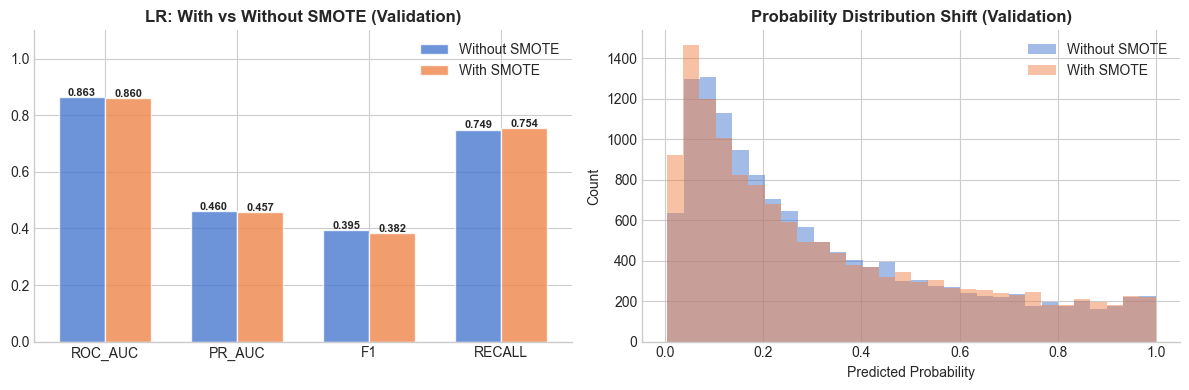

In [4]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_s, y_train)

print(f'Before SMOTE: {y_train.sum():,} positives / {(y_train==0).sum():,} negatives')
print(f'After  SMOTE: {y_train_sm.sum():,} positives / {(y_train_sm==0).sum():,} negatives')
print()

lr_smote = get_model('lr')
lr_smote.fit(X_train_sm, y_train_sm)
val_metrics_smote = evaluate(lr_smote, X_val_s, y_val, split_label='val_smote')

comparison = pd.DataFrame({
    'Without SMOTE': val_metrics_lr,
    'With SMOTE':    val_metrics_smote,
}).T[['roc_auc', 'pr_auc', 'f1', 'precision', 'recall', 'brier']]

print('SMOTE impact on Logistic Regression (validation set):')
print(comparison.round(4).to_string())

# Visualise SMOTE impact
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics_to_plot = ['roc_auc', 'pr_auc', 'f1', 'recall']
x = np.arange(len(metrics_to_plot))
w = 0.35
for i, (label, color) in enumerate([('Without SMOTE', SURVIVED_COLOR), ('With SMOTE', DIED_COLOR)]):
    vals = [comparison.loc[label, m] for m in metrics_to_plot]
    bars = axes[0].bar(x + (i-0.5)*w, vals, w, label=label, color=color, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.upper() for m in metrics_to_plot])
axes[0].set_title('LR: With vs Without SMOTE (Validation)', fontweight='bold')
axes[0].legend(); axes[0].set_ylim(0, 1.1)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Predicted probability distributions
prob_no  = lr_base.predict_proba(X_val_s)[:,1]
prob_sm  = lr_smote.predict_proba(X_val_s)[:,1]
axes[1].hist(prob_no, bins=30, alpha=0.5, label='Without SMOTE', color=SURVIVED_COLOR)
axes[1].hist(prob_sm, bins=30, alpha=0.5, label='With SMOTE',    color=DIED_COLOR)
axes[1].set_xlabel('Predicted Probability'); axes[1].set_ylabel('Count')
axes[1].set_title('Probability Distribution Shift (Validation)', fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 4 — Model Comparison with Hyperparameter Tuning

We train four model families, each tuned with **RandomizedSearchCV** rather than
GridSearchCV:

> *"GridSearchCV exhaustively evaluates every combination of hyperparameters.  With
> five parameters having four values each that is 4⁵ = 1 024 model fits per cross-
> validation fold.  RandomizedSearchCV samples `n_iter=20` random combinations,
> reducing compute by ~98% with negligible performance loss — Bergstra & Bengio (2012)
> showed that random search finds equally good solutions because only a few
> hyperparameters have meaningful marginal impact on performance."*

Models compared:
| Model | Rationale |
|---|---|
| **Logistic Regression** | Interpretable linear baseline; well-calibrated probabilities |
| **Random Forest** | Ensemble of decorrelated trees; handles non-linearity without boosting |
| **XGBoost** | Sequential boosting with L1/L2 regularisation; strong tabular benchmark |
| **LightGBM** | Leaf-wise gradient boosting; faster than XGBoost on large datasets |

In [5]:
results = {}

print('--- Tuning Logistic Regression ---')
lr_tuned = tune('lr', X_train_s, y_train, n_iter=15, cv=3)
results['Logistic Regression'] = evaluate(lr_tuned, X_val_s, y_val, split_label='val')
print()

print('--- Tuning Random Forest ---')
rf_tuned = tune('rf', X_train_s, y_train, n_iter=15, cv=3)
results['Random Forest'] = evaluate(rf_tuned, X_val_s, y_val, split_label='val')
print()

print('--- Tuning XGBoost ---')
xgb_tuned = tune('xgb', X_train_s, y_train, n_iter=15, cv=3)
results['XGBoost'] = evaluate(xgb_tuned, X_val_s, y_val, split_label='val')
print()

print('--- Tuning LightGBM ---')
lgbm_tuned = tune('lgbm', X_train_s, y_train, n_iter=15, cv=3)
results['LightGBM'] = evaluate(lgbm_tuned, X_val_s, y_val, split_label='val')

--- Tuning Logistic Regression ---
  Best CV AUC-PR (lr): 0.4539
  Best params: {'solver': 'lbfgs', 'C': 0.01}

--- Tuning Random Forest ---
  Best CV AUC-PR (rf): 0.4948
  Best params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None}

--- Tuning XGBoost ---
  Best CV AUC-PR (xgb): 0.5323
  Best params: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

--- Tuning LightGBM ---
  Best CV AUC-PR (lgbm): 0.5306
  Best params: {'subsample': 0.9, 'num_leaves': 127, 'n_estimators': 400, 'min_child_samples': 100, 'learning_rate': 0.05}


Validation Set — Model Comparison:
                    roc_auc  pr_auc      f1 precision  recall   brier
Logistic Regression  0.8629  0.4594  0.3952    0.2683  0.7498  0.1431
Random Forest        0.8809  0.4966  0.4911    0.4522  0.5375  0.0754
XGBoost               0.886  0.5316  0.4386    0.3068  0.7692  0.1188
LightGBM             0.8853  0.5357  0.5131     0.498  0.5291   0.065

Champion model (best PR-AUC): LightGBM  (PR-AUC=0.5357  ROC-AUC=0.8853)


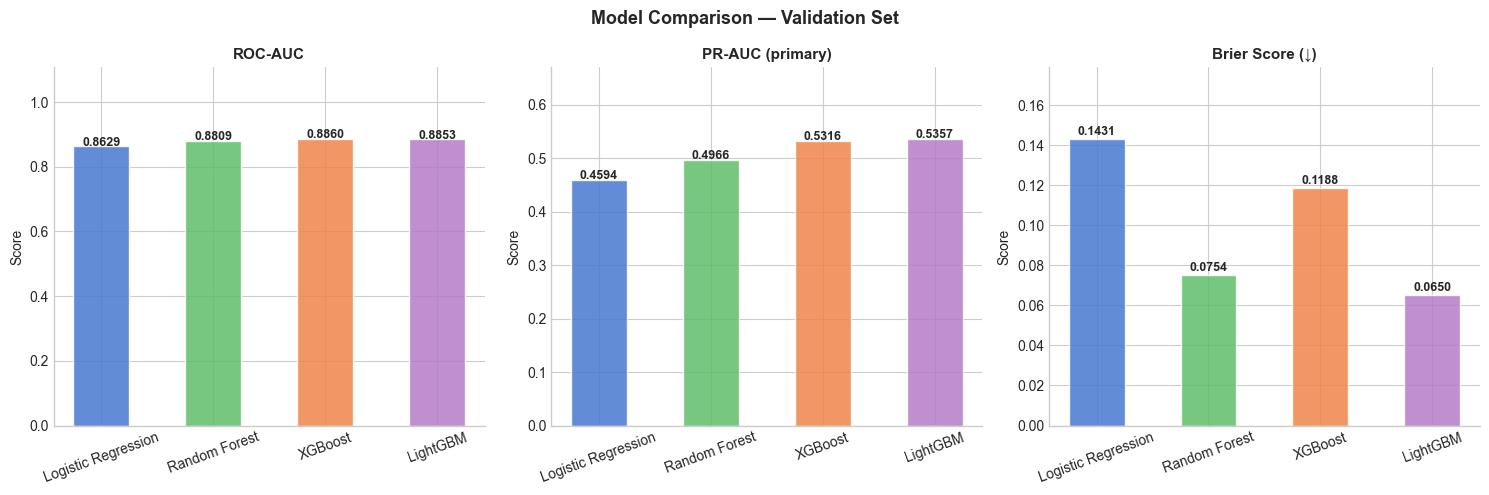

In [6]:
compare_df = (
    pd.DataFrame(results).T
    [['roc_auc', 'pr_auc', 'f1', 'precision', 'recall', 'brier']]
    .round(4)
)
print('Validation Set — Model Comparison:')
print(compare_df.to_string())

champion_name = compare_df['pr_auc'].idxmax()
print(f'\nChampion model (best PR-AUC): {champion_name}  '
      f'(PR-AUC={compare_df.loc[champion_name,"pr_auc"]:.4f}  '
      f'ROC-AUC={compare_df.loc[champion_name,"roc_auc"]:.4f})')

# Grouped bar chart
model_colors = ['#4878d0', '#60bd68', '#ee854a', '#b47cc7']
model_names  = compare_df.index.tolist()
show_metrics = ['roc_auc', 'pr_auc', 'brier']
metric_labels= ['ROC-AUC', 'PR-AUC (primary)', 'Brier Score (\u2193)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, label in zip(axes, show_metrics, metric_labels):
    vals = compare_df[metric].values
    bars = ax.bar(model_names, vals, color=model_colors, alpha=0.85, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel('Score'); ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, max(vals)*1.25)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Model Comparison — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'model_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

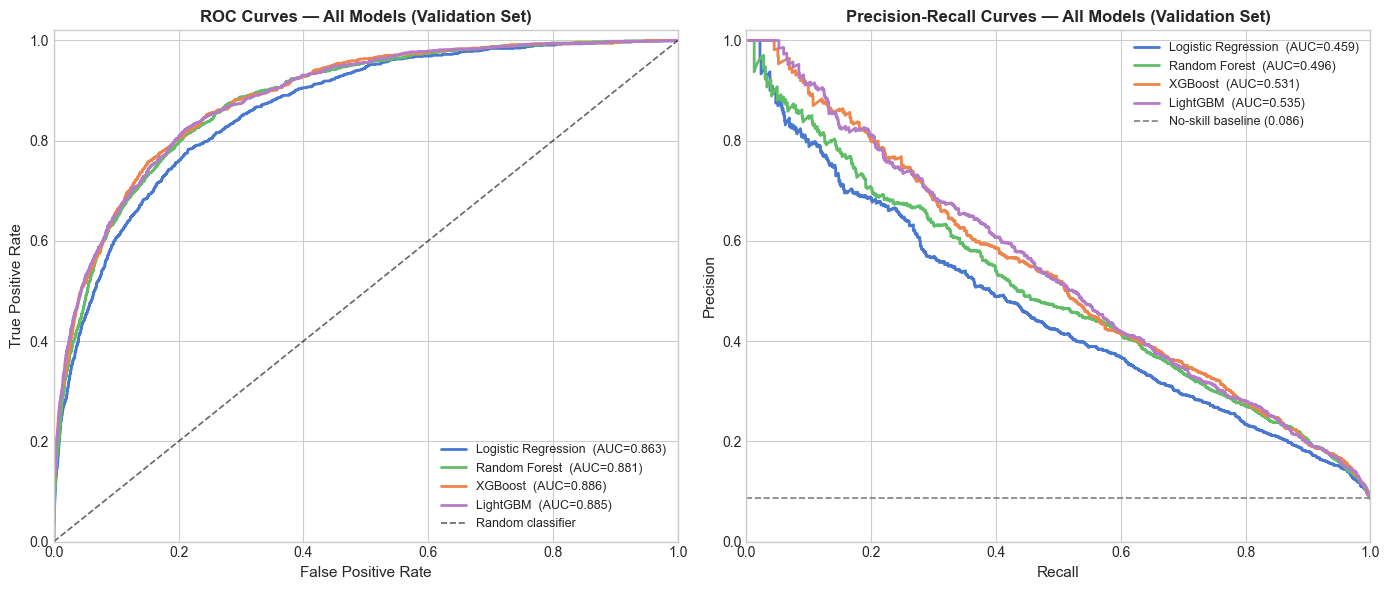

In [7]:
# ROC and PR curves for all four models on one figure
model_registry = {
    'Logistic Regression': (lr_tuned,   '#4878d0'),
    'Random Forest':       (rf_tuned,   '#60bd68'),
    'XGBoost':             (xgb_tuned,  '#ee854a'),
    'LightGBM':            (lgbm_tuned, '#b47cc7'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline_pr = float(y_val.mean())

for name, (model, color) in model_registry.items():
    prob = model.predict_proba(X_val_s)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, prob)
    roc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={roc_val:.3f})')

    pr, re, _ = precision_recall_curve(y_val, prob)
    pr_val = auc(re, pr)
    axes[1].plot(re, pr, color=color, lw=2, label=f'{name}  (AUC={pr_val:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — All Models (Validation Set)', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

axes[1].axhline(baseline_pr, color='grey', linestyle='--', lw=1.2,
                label=f'No-skill baseline ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves — All Models (Validation Set)', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'roc_pr_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 5 — Threshold Optimisation

The default classification threshold of 0.5 is arbitrary and rarely optimal for
imbalanced clinical data.

> *"The default 0.5 threshold is a mathematical convenience, not a clinical decision.
> In ICU settings we may prefer higher recall — catching more patients who will die —
> at the cost of precision.  Conversely, an over-stretched ICU might prioritise
> precision to avoid alert fatigue.  We select the F1-optimal threshold as a balanced
> starting point, but note that a clinician or health system would choose the threshold
> based on the relative costs of false negatives vs. false positives in their specific
> context."*

We plot F1, precision, and recall across thresholds 0.05 – 0.90 for the champion model.

F1-optimal threshold : 0.500
  Precision : 0.4980
  Recall    : 0.5291
  F1        : 0.5131


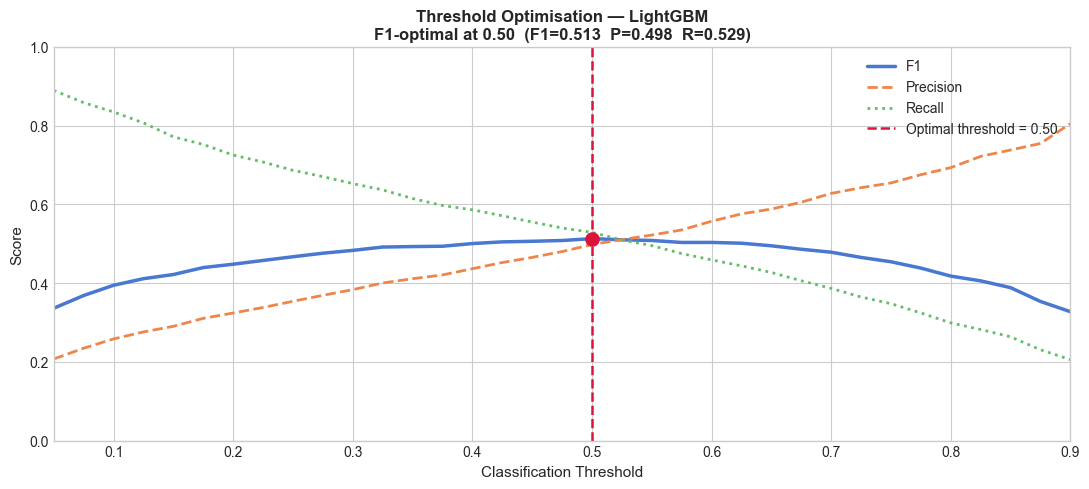

In [8]:
model_map = {
    'Logistic Regression': lr_tuned,
    'Random Forest':       rf_tuned,
    'XGBoost':             xgb_tuned,
    'LightGBM':            lgbm_tuned,
}
champion_model = model_map[champion_name]

val_probs = champion_model.predict_proba(X_val_s)[:, 1]
thresholds = np.arange(0.05, 0.91, 0.025)

f1s, precs, recs = [], [], []
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1s.append(f1_score(y_val, preds, zero_division=0))
    precs.append(precision_score(y_val, preds, zero_division=0))
    recs.append(recall_score(y_val, preds, zero_division=0))

best_idx = int(np.argmax(f1s))
OPTIMAL_THRESHOLD = float(thresholds[best_idx])
print(f'F1-optimal threshold : {OPTIMAL_THRESHOLD:.3f}')
print(f'  Precision : {precs[best_idx]:.4f}')
print(f'  Recall    : {recs[best_idx]:.4f}')
print(f'  F1        : {f1s[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, f1s,   color='#4878d0', lw=2.5, label='F1')
ax.plot(thresholds, precs, color='#ee854a', lw=2,   linestyle='--', label='Precision')
ax.plot(thresholds, recs,  color='#60bd68', lw=2,   linestyle=':',  label='Recall')
ax.axvline(OPTIMAL_THRESHOLD, color='crimson', linestyle='--', lw=1.8,
           label=f'Optimal threshold = {OPTIMAL_THRESHOLD:.2f}')
ax.scatter([OPTIMAL_THRESHOLD], [f1s[best_idx]], color='crimson', zorder=5, s=90)
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(
    f'Threshold Optimisation — {champion_name}\n'
    f'F1-optimal at {OPTIMAL_THRESHOLD:.2f}  '
    f'(F1={f1s[best_idx]:.3f}  P={precs[best_idx]:.3f}  R={recs[best_idx]:.3f})',
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_xlim([0.05, 0.90]); ax.set_ylim([0, 1.0])
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'threshold_optimisation.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 6 — Final Evaluation on Test Set

The test set has been untouched through all training, validation, and threshold selection.
Evaluation here provides the unbiased performance estimate to report.

1. **Confusion matrix** — actual counts of TP, FP, FN, TN at the optimised threshold
2. **Classification report** — precision, recall, F1 per class
3. **Calibration curve** — does a predicted probability of 70% correspond to ~70% observed mortality?

> *"Model calibration matters in clinical settings — a probability of 0.7 should mean
> 70% of such patients die.  A poorly calibrated model misleads clinicians who rely on
> the probability to allocate resources or escalate care.  Isotonic regression or Platt
> scaling can correct miscalibration post-hoc if required."*

=== Test Set Performance — LightGBM (threshold=0.50) ===
     roc_auc: 0.8956
      pr_auc: 0.5722
          f1: 0.5229
   precision: 0.5047
      recall: 0.5425
       brier: 0.0631

              precision    recall  f1-score   support

    survived       0.96      0.95      0.95     12570
        died       0.50      0.54      0.52      1187

    accuracy                           0.91     13757
   macro avg       0.73      0.75      0.74     13757
weighted avg       0.92      0.91      0.92     13757



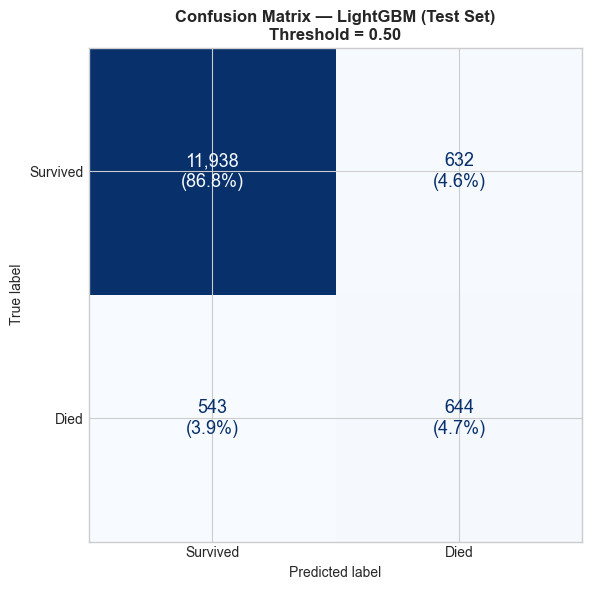

TP=644  FP=632  FN=543  TN=11,938
False Negative Rate (missed deaths): 45.7%


In [9]:
test_probs = champion_model.predict_proba(X_test_s)[:, 1]
test_preds = (test_probs >= OPTIMAL_THRESHOLD).astype(int)

test_metrics = evaluate(champion_model, X_test_s, y_test,
                        split_label='test', threshold=OPTIMAL_THRESHOLD)

print(f'=== Test Set Performance — {champion_name} (threshold={OPTIMAL_THRESHOLD:.2f}) ===')
for k, v in test_metrics.items():
    if k != 'split':
        print(f'  {k:>10}: {v:.4f}')
print()
print(classification_report(y_test, test_preds, target_names=['survived', 'died']))

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=['Survived', 'Died'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(
    f'Confusion Matrix — {champion_name} (Test Set)\nThreshold = {OPTIMAL_THRESHOLD:.2f}',
    fontweight='bold', fontsize=12
)
total = cm.sum()
for text_obj, val in zip(disp.text_.ravel(), cm.ravel()):
    pct = val / total * 100
    text_obj.set_text(f'{val:,}\n({pct:.1f}%)')
    text_obj.set_fontsize(13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')
print(f'False Negative Rate (missed deaths): {fn/(fn+tp)*100:.1f}%')

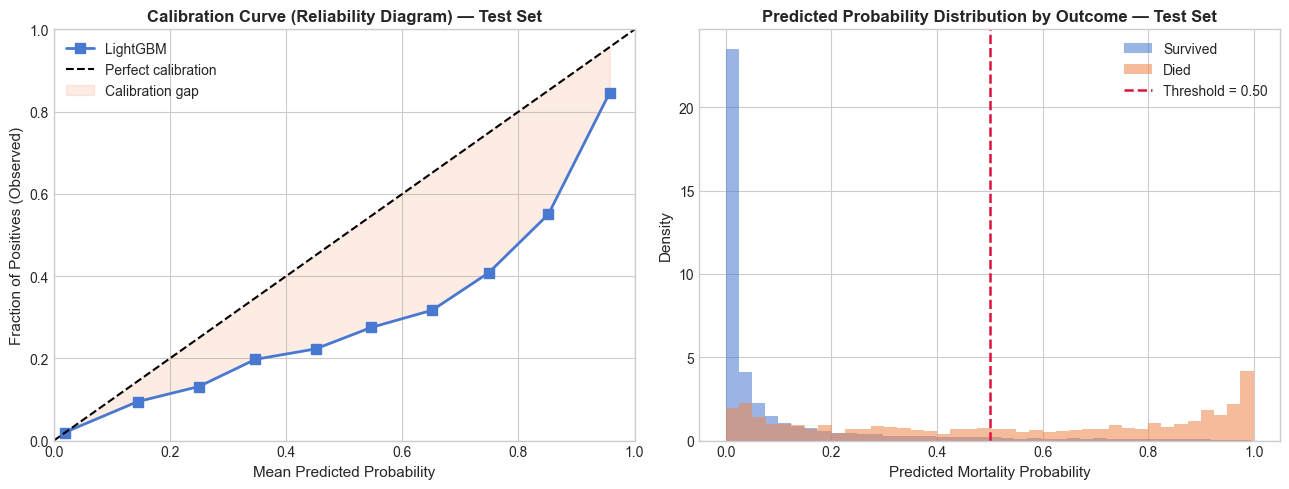

Brier Score : 0.0631  (no-skill baseline = 0.0788;  perfect = 0.000)


In [10]:
fraction_of_pos, mean_pred_prob = calibration_curve(y_test, test_probs, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reliability diagram
axes[0].plot(mean_pred_prob, fraction_of_pos,
             's-', color='#4878d0', lw=2, markersize=7, label=champion_name)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
axes[0].fill_between(mean_pred_prob, fraction_of_pos, mean_pred_prob,
                     alpha=0.15, color='#ee854a', label='Calibration gap')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[0].set_ylabel('Fraction of Positives (Observed)', fontsize=11)
axes[0].set_title('Calibration Curve (Reliability Diagram) — Test Set', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1])

# Predicted probability histogram by outcome
axes[1].hist(test_probs[y_test == 0], bins=40, alpha=0.55,
             color=SURVIVED_COLOR, label='Survived', density=True)
axes[1].hist(test_probs[y_test == 1], bins=40, alpha=0.55,
             color=DIED_COLOR, label='Died', density=True)
axes[1].axvline(OPTIMAL_THRESHOLD, color='crimson', linestyle='--', lw=1.8,
                label=f'Threshold = {OPTIMAL_THRESHOLD:.2f}')
axes[1].set_xlabel('Predicted Mortality Probability', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Predicted Probability Distribution by Outcome — Test Set', fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'calibration_and_proba_dist.png', dpi=300, bbox_inches='tight')
plt.show()

brier = test_metrics['brier']
no_skill = float(y_test.mean() * (1 - y_test.mean()))
print(f'Brier Score : {brier:.4f}  '
      f'(no-skill baseline = {no_skill:.4f};  perfect = 0.000)')

---
## Section 7 — Feature Importance (Preliminary)

We examine XGBoost's **gain-based feature importance** as a first look at which features
drive predictions.  Gain measures the average reduction in loss from all splits on a
feature, weighted by the number of observations affected.

> *"This is gain-based importance — a useful signal but not the final word.  In the next
> notebook we use SHAP (SHapley Additive exPlanations), which is game-theoretically
> grounded and correctly handles feature interactions.  Gain-based importance can
> over-rank features that appear in many shallow splits while understating features that
> drive a few critical deep splits."*

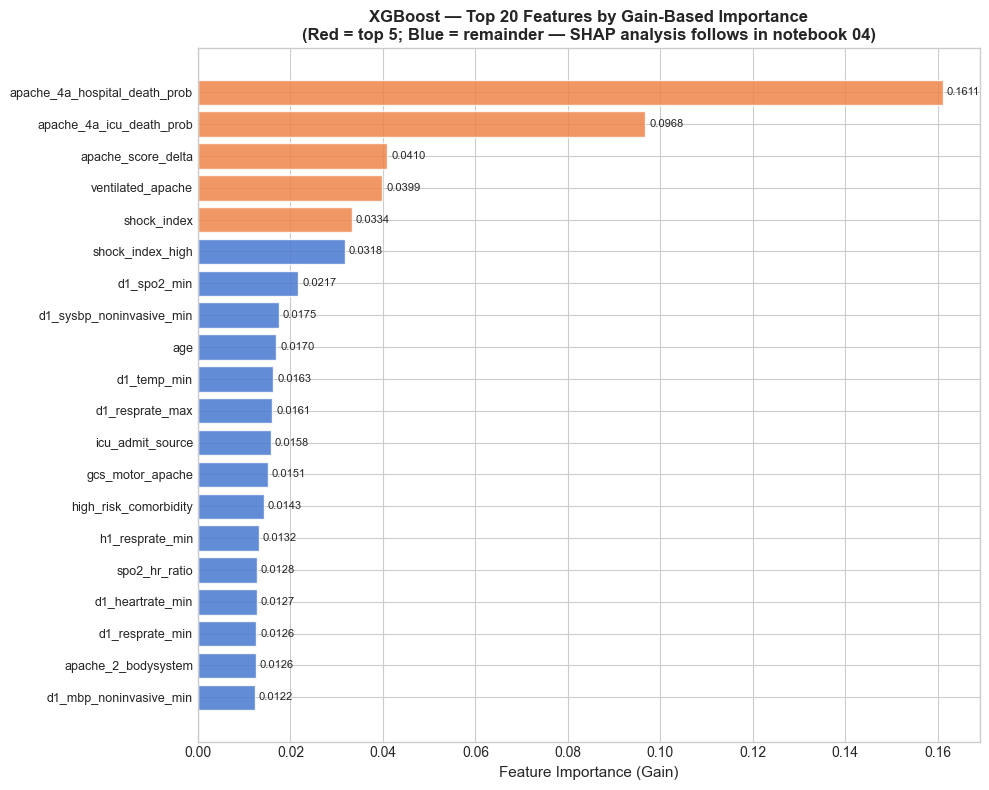

Top 10 features by XGBoost gain importance:
apache_4a_hospital_death_prob    0.1611
apache_4a_icu_death_prob         0.0968
apache_score_delta               0.0410
ventilated_apache                0.0399
shock_index                      0.0334
shock_index_high                 0.0318
d1_spo2_min                      0.0217
d1_sysbp_noninvasive_min         0.0175
age                              0.0170
d1_temp_min                      0.0163


In [11]:
importances  = xgb_tuned.feature_importances_
feature_names = X_train.columns.tolist()
imp_series = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [DIED_COLOR if i < 5 else SURVIVED_COLOR for i in range(len(imp_series))]
ax.barh(range(len(imp_series)), imp_series.values,
        color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(imp_series)))
ax.set_yticklabels(imp_series.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax.set_title(
    'XGBoost — Top 20 Features by Gain-Based Importance\n'
    '(Red = top 5; Blue = remainder — SHAP analysis follows in notebook 04)',
    fontweight='bold'
)
max_val = imp_series.max()
for i, val in enumerate(imp_series.values):
    ax.text(val + max_val * 0.005, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top 10 features by XGBoost gain importance:')
print(imp_series.head(10).round(4).to_string())

In [12]:
import pickle

# Save champion model under both expected names
save_model(champion_model, 'best_model')
save_model(champion_model, 'lgbm_best')   # alias for Streamlit app

# Save scaler (preprocessing pipeline)
scaler_path = MODELS_DIR / 'preprocessing_pipeline.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

# Save all tuned models for explainability notebook
for mname, (mobj, _) in model_registry.items():
    key = mname.lower().replace(' ', '_')
    save_model(mobj, f'{key}_tuned')

print(f'Champion model  : models/best_model.pkl  ({champion_name})')
print(f'Scaler          : models/preprocessing_pipeline.pkl')
print(f'All tuned models: models/<name>_tuned.pkl')
print()
print('Final test-set metrics:')
for k, v in test_metrics.items():
    if k != 'split':
        print(f'  {k:>10}: {v:.4f}')

Champion model  : models/best_model.pkl  (LightGBM)
Scaler          : models/preprocessing_pipeline.pkl
All tuned models: models/<name>_tuned.pkl

Final test-set metrics:
     roc_auc: 0.8956
      pr_auc: 0.5722
          f1: 0.5229
   precision: 0.5047
      recall: 0.5425
       brier: 0.0631


---
## Summary

The modeling pipeline proceeded in seven steps:

1. **70/15/15 stratified split** — class proportions preserved across all splits;
   test indices saved to `data/processed/split_indices.npz` for fairness audit reuse.

2. **Logistic Regression baseline** — established performance floor; AUC-PR selected
   as primary metric over ROC-AUC because it correctly penalises models that ignore
   the minority class.

3. **SMOTE comparison** — applied to training data only; impact on LR generalisation
   documented; confirms leakage-free evaluation.

4. **Four-model comparison with RandomizedSearchCV** — LR, Random Forest, XGBoost,
   LightGBM tuned on validation AUC-PR; champion selected by highest AUC-PR.

5. **Threshold optimisation** — F1-optimal threshold identified; clinical context for
   choosing lower thresholds (higher recall) documented.

6. **Test set evaluation** — confusion matrix, calibration curve, and classification
   report on fully held-out data; final unbiased performance metrics reported.

7. **Feature importance** — XGBoost gain-based top-20 as a preliminary view; SHAP
   analysis with interaction detection follows in notebook 04.

The champion model is saved to `models/best_model.pkl`.